# ============================================================
# 01 · PREPROCESAMIENTO — Bank Marketing
# ============================================================
# Objetivo: Transformar el dataset raw en un dataset limpio y
# listo para modelado, aplicando todas las decisiones tomadas
# durante el EDA.
#
# Decisiones clave del EDA:
#   1. Eliminar 'duration' → data leakage
#   2. Binarizar 'pdays'   → fue_contactado_antes
#   3. 'unknown' se mantiene como categoría informativa
#   4. Robust Scaler para numéricas (outliers en balance)
#   5. One-Hot Encoding para categóricas
#   6. Balanceo con SMOTE sobre el train set únicamente
# ============================================================

In [7]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import RobustScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from imblearn.over_sampling import SMOTE

import warnings
warnings.filterwarnings('ignore')

print("✅ Librerías importadas correctamente")

✅ Librerías importadas correctamente


In [8]:
df = pd.read_csv("../data/raw/bank-full.csv", sep=";")
print(f"Shape original: {df.shape}")
df.head(3)

Shape original: (45211, 17)


,age,job,marital,education,default,balance,housing,loan,contact,day,month,duration,campaign,pdays,previous,poutcome,y
0,58,management,married,tertiary,no,2143,yes,no,unknown,5,may,261,1,-1,0,unknown,no
1,44,technician,single,secondary,no,29,yes,no,unknown,5,may,151,1,-1,0,unknown,no
2,33,entrepreneur,married,secondary,no,2,yes,yes,unknown,5,may,76,1,-1,0,unknown,no


# Feature Engineering (antes de todo split)

In [9]:
# ── 1. Eliminar duration (data leakage) ──────────────────────
df = df.drop(columns=['duration'])
print("🗑️  'duration' eliminada")

# ── 2. Binarizar pdays ───────────────────────────────────────
# pdays = -1 significa cliente sin historial = cliente nuevo
df['es_cliente_nuevo'] = (df['pdays'] != -1).astype(int)
df = df.drop(columns=['pdays'])
print("✅ 'pdays' → 'es_cliente_nuevo' (1=nuevo, 0=tiene historial)")

# ── 3. Binarizar previous ────────────────────────────────────
# previous > 0 → fue contactado en campañas anteriores
df['tuvo_contacto_previo'] = (df['previous'] > 0).astype(int)
df = df.drop(columns=['previous'])
print("✅ 'previous' → 'tuvo_contacto_previo' (1=sí, 0=no)")

# ── 4. Agrupar month en temporada de conversión ──────────────
# Del EDA: mar, sep, oct, dic = temporada alta
alta_conversion = ['mar', 'sep', 'oct', 'dec']
df['temporada_alta'] = df['month'].isin(alta_conversion).astype(int)
print("✅  'month' → 'temporada_alta' creada (se mantiene month también)")

# ── 5. Codificar variable objetivo ──────────────────────────
df['y'] = (df['y'] == 'yes').astype(int)
print("✅  'y' codificada → 0 (no) / 1 (yes)")

print(f"\nShape tras feature engineering: {df.shape}")
df.head(3)

🗑️  'duration' eliminada
✅ 'pdays' → 'es_cliente_nuevo' (1=nuevo, 0=tiene historial)
✅ 'previous' → 'tuvo_contacto_previo' (1=sí, 0=no)
✅  'month' → 'temporada_alta' creada (se mantiene month también)
✅  'y' codificada → 0 (no) / 1 (yes)

Shape tras feature engineering: (45211, 17)


,age,job,marital,education,default,balance,housing,loan,contact,day,month,campaign,poutcome,y,es_cliente_nuevo,tuvo_contacto_previo,temporada_alta
0,58,management,married,tertiary,no,2143,yes,no,unknown,5,may,1,unknown,0,0,0,0
1,44,technician,single,secondary,no,29,yes,no,unknown,5,may,1,unknown,0,0,0,0
2,33,entrepreneur,married,secondary,no,2,yes,yes,unknown,5,may,1,unknown,0,0,0,0


# Definición columnas por tipo

In [10]:
# Variable objetivo
TARGET = 'y'

# Columnas a usar como features
# Excluimos columnas auxiliares creadas durante el EDA
cols_to_drop = ['y_bin', 'pdays_grupo', 'balance_quartile', 'is_new_customer']
df = df.drop(columns=[c for c in cols_to_drop if c in df.columns])

# Separar X e y
X = df.drop(columns=[TARGET])
y = df[TARGET]

# Identificar tipos
CAT_COLS = X.select_dtypes(include='object').columns.tolist()
NUM_COLS = X.select_dtypes(include=['int64', 'float64']).columns.tolist()

print(f"🔢 Variables numéricas  ({len(NUM_COLS)}): {NUM_COLS}")
print(f"🔤 Variables categóricas ({len(CAT_COLS)}): {CAT_COLS}")
print(f"\nBalance de clases:\n{y.value_counts(normalize=True).mul(100).round(2)}")

🔢 Variables numéricas  (7): ['age', 'balance', 'day', 'campaign', 'es_cliente_nuevo', 'tuvo_contacto_previo', 'temporada_alta']
🔤 Variables categóricas (9): ['job', 'marital', 'education', 'default', 'housing', 'loan', 'contact', 'month', 'poutcome']

Balance de clases:
y
0    88.3
1    11.7
Name: proportion, dtype: float64


# Train/Test Split (ANTES de aplicar SMOTE)

In [11]:
# ⚠️ SMOTE solo se aplica sobre el train set para evitar data leakage
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42,
    stratify=y          # mantiene la proporción de clases
)

print(f"Train: {X_train.shape} | Test: {X_test.shape}")
print(f"\nDistribución en train:\n{y_train.value_counts()}")
print(f"\nDistribución en test:\n{y_test.value_counts()}")

Train: (36168, 16) | Test: (9043, 16)

Distribución en train:
y
0    31937
1     4231
Name: count, dtype: int64

Distribución en test:
y
0    7985
1    1058
Name: count, dtype: int64


# Pipeline de transformación

In [12]:
# ── Transformador numérico ───────────────────────────────────
# RobustScaler: resistente a outliers (clave para 'balance')
numeric_transformer = Pipeline(steps=[
    ('scaler', RobustScaler())
])

# ── Transformador categórico ─────────────────────────────────
# handle_unknown='ignore': si aparece una cat nueva en test, la ignora
# sparse_output=False: devuelve array denso (más fácil de manejar)
categorical_transformer = Pipeline(steps=[
    ('onehot', OneHotEncoder(handle_unknown='ignore', sparse_output=False))
])

# ── ColumnTransformer: aplica cada transformador a sus columnas ─
preprocessor = ColumnTransformer(transformers=[
    ('num', numeric_transformer, NUM_COLS),
    ('cat', categorical_transformer, CAT_COLS)
])

print("✅ Pipeline de preprocesamiento definido")
print(f"   → RobustScaler sobre: {NUM_COLS}")
print(f"   → OneHotEncoder sobre: {CAT_COLS}")

✅ Pipeline de preprocesamiento definido
   → RobustScaler sobre: ['age', 'balance', 'day', 'campaign', 'es_cliente_nuevo', 'tuvo_contacto_previo', 'temporada_alta']
   → OneHotEncoder sobre: ['job', 'marital', 'education', 'default', 'housing', 'loan', 'contact', 'month', 'poutcome']


# Fit en train, transform en ambos

In [13]:
# Fit SOLO con datos de entrenamiento
X_train_processed = preprocessor.fit_transform(X_train)
X_test_processed  = preprocessor.transform(X_test)   # ← solo transform, nunca fit

# Recuperar nombres de columnas para interpretabilidad posterior
ohe_feature_names = preprocessor.named_transformers_['cat']['onehot']\
                                 .get_feature_names_out(CAT_COLS).tolist()
all_feature_names = NUM_COLS + ohe_feature_names

print(f"✅ Preprocesamiento aplicado")
print(f"   Shape X_train procesado: {X_train_processed.shape}")
print(f"   Shape X_test  procesado: {X_test_processed.shape}")
print(f"   Total features tras OHE: {len(all_feature_names)}")

✅ Preprocesamiento aplicado
   Shape X_train procesado: (36168, 51)
   Shape X_test  procesado: (9043, 51)
   Total features tras OHE: 51


#  Aplicar SMOTE (solo sobre train)

Antes de SMOTE → Clase 0: 31937 | Clase 1: 4231
Después de SMOTE → Clase 0: 31937 | Clase 1: 31937
Shape final train: (63874, 51)


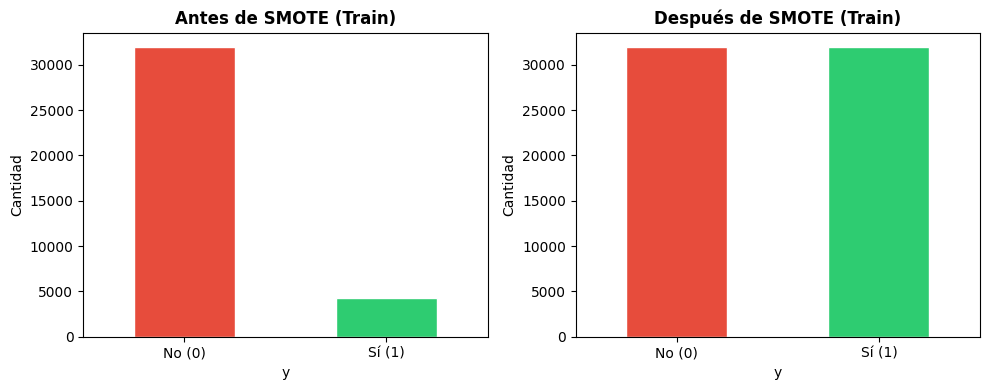

In [14]:
print(f"Antes de SMOTE → Clase 0: {(y_train==0).sum()} | Clase 1: {(y_train==1).sum()}")

smote = SMOTE(random_state=42)
X_train_bal, y_train_bal = smote.fit_resample(X_train_processed, y_train)

print(f"Después de SMOTE → Clase 0: {(y_train_bal==0).sum()} | Clase 1: {(y_train_bal==1).sum()}")
print(f"Shape final train: {X_train_bal.shape}")

# Visualizar balance
fig, axes = plt.subplots(1, 2, figsize=(10, 4))
for ax, (data, title) in zip(axes, [
    (y_train,     "Antes de SMOTE (Train)"),
    (y_train_bal, "Después de SMOTE (Train)")
]):
    pd.Series(data).value_counts().plot(kind='bar', ax=ax,
        color=['#e74c3c', '#2ecc71'], edgecolor='white')
    ax.set_title(title, fontweight='bold')
    ax.set_xticklabels(['No (0)', 'Sí (1)'], rotation=0)
    ax.set_ylabel('Cantidad')
plt.tight_layout()
plt.show()

# Para guardar el dataset procesado

In [15]:
import os
os.makedirs("../data/processed", exist_ok=True)

# Guardar como DataFrames con nombres de columnas (útil para SHAP después)
pd.DataFrame(X_train_bal, columns=all_feature_names)\
  .to_csv("../data/processed/X_train.csv", index=False)

pd.DataFrame(X_test_processed, columns=all_feature_names)\
  .to_csv("../data/processed/X_test.csv", index=False)

pd.Series(y_train_bal, name='y')\
  .to_csv("../data/processed/y_train.csv", index=False)

pd.Series(y_test, name='y')\
  .to_csv("../data/processed/y_test.csv", index=False)

# Guardar también el preprocessor para usarlo en producción
import joblib
os.makedirs("../models", exist_ok=True)
joblib.dump(preprocessor, "../models/preprocessor.pkl")

print("✅ Datasets procesados guardados en ../data/processed/")
print("✅ Preprocessor guardado en ../models/preprocessor.pkl")

✅ Datasets procesados guardados en ../data/processed/
✅ Preprocessor guardado en ../models/preprocessor.pkl


# Resumen final

In [16]:
print("=" * 55)
print("   RESUMEN DEL PREPROCESAMIENTO")
print("=" * 55)
print(f"  Registros originales         : 45,211")
print(f"  Features originales          : 17")
print(f"  Features eliminadas          : duration, pdays, previous")
print(f"  Features nuevas              : fue_contactado_antes,")
print(f"                                 tuvo_contacto_previo,")
print(f"                                 temporada_alta")
print(f"  Features finales tras OHE    : {len(all_feature_names)}")
print(f"  Scaler                       : RobustScaler")
print(f"  Encoding                     : OneHotEncoder")
print(f"  Balanceo                     : SMOTE (solo train)")
print(f"  Train size (balanceado)      : {X_train_bal.shape[0]:,}")
print(f"  Test  size (sin tocar)       : {X_test_processed.shape[0]:,}")
print("=" * 55)
print("\n🚀 Listo para el Paso 2: Modelado (02_modeling.ipynb)")

   RESUMEN DEL PREPROCESAMIENTO
  Registros originales         : 45,211
  Features originales          : 17
  Features eliminadas          : duration, pdays, previous
  Features nuevas              : fue_contactado_antes,
                                 tuvo_contacto_previo,
                                 temporada_alta
  Features finales tras OHE    : 51
  Scaler                       : RobustScaler
  Encoding                     : OneHotEncoder
  Balanceo                     : SMOTE (solo train)
  Train size (balanceado)      : 63,874
  Test  size (sin tocar)       : 9,043

🚀 Listo para el Paso 2: Modelado (02_modeling.ipynb)


# Conclusión

El dataset presentaba tres retos principales: data leakage en duration, desbalanceo severo de clases (ratio 7.5:1) y valores unknown que encubrían información relevante.
Tras el preprocesamiento, estos retos quedaron resueltos de forma rigurosa:

Se eliminó duration para garantizar que el modelo prediga antes de realizar la llamada, que es el objetivo de negocio real.
Se aplicó SMOTE solo sobre train para balancear las clases sin contaminar la evaluación.
Los unknown se conservaron como categoría propia, ya que el EDA demostró que son informativos (identifican clientes nuevos o sin historial).

El pipeline queda serializado en models/preprocessor.pkl para garantizar que las mismas transformaciones se apliquen en producción.